# 04 — Modelagem de Machine Learning

**Objetivo:** avaliar modelos de previsão para preços de combustíveis e segmentar municípios por perfil de preço.

## Fluxo (CRISP-DM)

1. **Entendimento do problema:** previsão de preços e análise de perfis regionais.
2. **Entendimento dos dados:** série mensal (2004–2025), com variáveis externas de câmbio e Brent.
3. **Preparação:** criação de lags, médias móveis e componentes sazonais.
4. **Modelagem:** Random Forest e Gradient Boosting para previsão; KMeans para clustering.
5. **Avaliação:** MAE, RMSE e R² com validação temporal (TimeSeriesSplit).
6. **Aplicação:** integração dos resultados ao dashboard Streamlit.

**Modelos desta etapa**
- Previsão de preço: Random Forest e Gradient Boosting
- Segmentação de municípios: KMeans


In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.ml import (
    preparar_features_temporais, treinar_modelo_previsao,
    prever_proximo_periodo, clustering_municipios
)
from src.utils import DATA_PROCESSED, construir_coluna_data

%matplotlib inline

In [2]:
import duckdb

PARQUET = str(DATA_PROCESSED / 'combustiveis_brasil.parquet')

df_mensal = pd.read_parquet(DATA_PROCESSED / 'agg_mensal_nacional.parquet')

with duckdb.connect() as con:
    n = con.execute(f"SELECT COUNT(*) FROM read_parquet('{PARQUET}')").fetchone()[0]

print(f"Dataset: {n:,} registros (acessado via DuckDB)")
print(f"Mensal: {len(df_mensal)} registros")

Dataset: 20,484,968 registros (acessado via DuckDB)
Mensal: 1070 registros


## 4.1 — Previsão de Preço: Preparação de Features

In [3]:
gasolina_mensal = df_mensal[df_mensal['produto_padronizado'] == 'Gasolina Comum'].copy()
print(f"Série temporal: {len(gasolina_mensal)} meses")

df_features = preparar_features_temporais(gasolina_mensal, coluna_preco='preco_medio', lags=6, target_retorno=True)
print(f"Após features: {len(df_features)} registros, {len(df_features.columns)} colunas")
print(f"\nFeatures criadas:")
print([c for c in df_features.columns if c.startswith(('lag_', 'media_', 'variacao_', 'mes_'))])
df_features.tail()

Série temporal: 220 meses
Após features: 214 registros, 18 colunas

Features criadas:
['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'media_movel_3m', 'media_movel_6m', 'variacao_pct', 'variacao_pct_3m', 'mes_sin', 'mes_cos']


,ano,mes,produto_padronizado,preco_medio,preco_mediano,n_registros,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,media_movel_3m,media_movel_6m,variacao_pct,variacao_pct_3m,mes_sin,mes_cos
1051,2025,8,Gasolina Comum,6.182066,6.15,14266,6.211219,6.226324,6.283602,6.316235,6.349952,6.367177,6.206536,6.261566,-0.004694,-0.016159,-8.660254e-01,-5.000000e-01
1052,2025,9,Gasolina Comum,6.191606,6.16,17103,6.182066,6.211219,6.226324,6.283602,6.316235,6.349952,6.194964,6.235175,0.001543,-0.005576,-1.000000e+00,-1.836970e-16
1067,2025,10,Gasolina Comum,6.215174,6.19,16621,6.191606,6.182066,6.211219,6.226324,6.283602,6.316235,6.196282,6.218332,0.003806,0.000637,-8.660254e-01,5.000000e-01
711,2025,11,Gasolina Comum,6.187876,6.18,16435,6.215174,6.191606,6.182066,6.211219,6.226324,6.283602,6.198219,6.202378,-0.004392,0.000940,-5.000000e-01,8.660254e-01
457,2025,12,Gasolina Comum,6.203292,6.19,19948,6.187876,6.215174,6.191606,6.182066,6.211219,6.226324,6.202114,6.198539,0.002491,0.001887,-2.449294e-16,1.000000e+00


## 4.2 — Treinamento: Random Forest

Treinamento do **Random Forest** com validação temporal, seguido da leitura das métricas e da importância das features.


In [4]:
resultado_rf = treinar_modelo_previsao(
    df_features, coluna_preco='preco_medio', modelo_tipo='random_forest'
)

print("\n=== Métricas (Validação Cruzada Temporal) ===")
for metrica, valores in resultado_rf['metricas_cv'].items():
    print(f"{metrica.upper()}: {valores['media']:.4f} (+/- {valores['std']:.4f})")

print("\n=== Importância das Features ===")
display(resultado_rf['importancia_features'])


=== Métricas (Validação Cruzada Temporal) ===
MAE: 0.0146 (+/- 0.0076)
RMSE: 0.0208 (+/- 0.0115)
R2: -0.0287 (+/- 0.4784)

=== Importância das Features ===


,feature,importancia
8,variacao_pct_3m,0.654831
2,lag_3,0.069155
0,lag_1,0.047410
10,mes_cos,0.039105
1,lag_2,0.037859
9,mes_sin,0.030562
5,lag_6,0.029735
3,lag_4,0.026705
6,media_movel_3m,0.022956
4,lag_5,0.022670


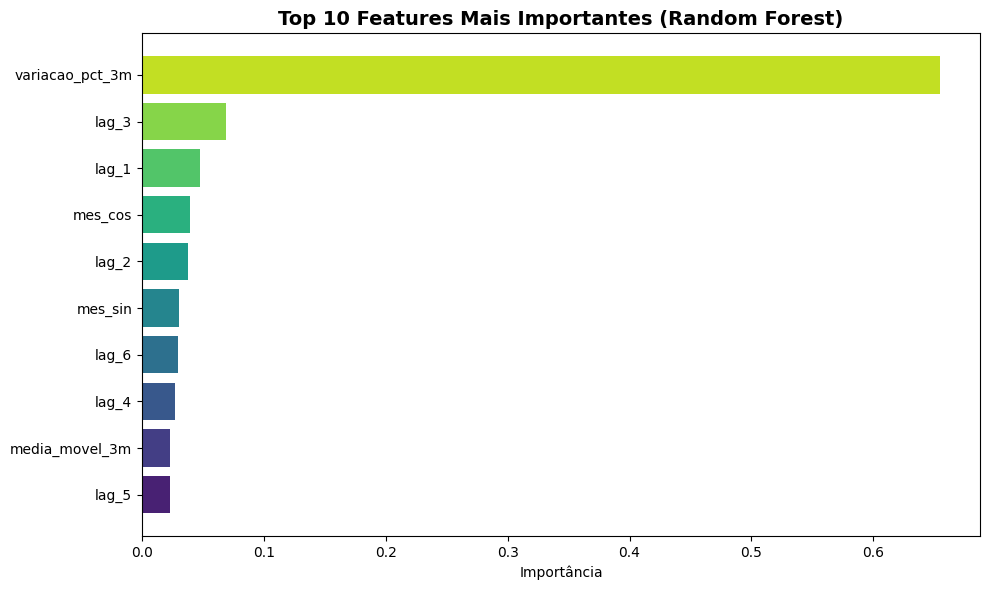

In [5]:
imp = resultado_rf['importancia_features'].head(10)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(imp['feature'][::-1], imp['importancia'][::-1], color=sns.color_palette('viridis', len(imp)))
ax.set_title('Top 10 Features Mais Importantes (Random Forest)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importância')
plt.tight_layout()
plt.savefig('../data/processed/fig_importancia_features.png', dpi=150, bbox_inches='tight')
plt.show()

Treinamento do **Gradient Boosting** no mesmo split temporal, para comparação direta com o Random Forest.


In [6]:
resultado_gb = treinar_modelo_previsao(
    df_features, coluna_preco='preco_medio', modelo_tipo='gradient_boosting'
)

print("\n=== Comparação de Modelos ===")
print(f"{'Métrica':<10} {'Random Forest':>20} {'Gradient Boosting':>20}")
print('-' * 52)
for metrica in ['mae', 'rmse', 'r2']:
    rf_val = resultado_rf['metricas_cv'][metrica]['media']
    gb_val = resultado_gb['metricas_cv'][metrica]['media']
    melhor = '← ✓' if (metrica == 'r2' and rf_val > gb_val) or (metrica != 'r2' and rf_val < gb_val) else '→ ✓'
    print(f"{metrica.upper():<10} {rf_val:>20.4f} {gb_val:>20.4f}  {melhor}")


=== Comparação de Modelos ===
Métrica           Random Forest    Gradient Boosting
----------------------------------------------------
MAE                      0.0146               0.0175  ← ✓
RMSE                     0.0208               0.0233  ← ✓
R2                      -0.0287              -0.6278  ← ✓


Com o modelo selecionado, geramos a projeção dos próximos meses.


In [7]:
melhor_modelo = resultado_rf

previsoes = prever_proximo_periodo(
    melhor_modelo, df_features, meses_futuro=6, coluna_preco='preco_medio'
)

print("\n=== Previsão de Preço — Gasolina Comum ===")
for _, row in previsoes.iterrows():
    print(f"{row['data'].strftime('%B %Y')}: R$ {row['preco_medio']:.2f}")


=== Previsão de Preço — Gasolina Comum ===
January 2026: R$ 6.21
February 2026: R$ 6.21
March 2026: R$ 6.21
April 2026: R$ 6.20
May 2026: R$ 6.19
June 2026: R$ 6.19


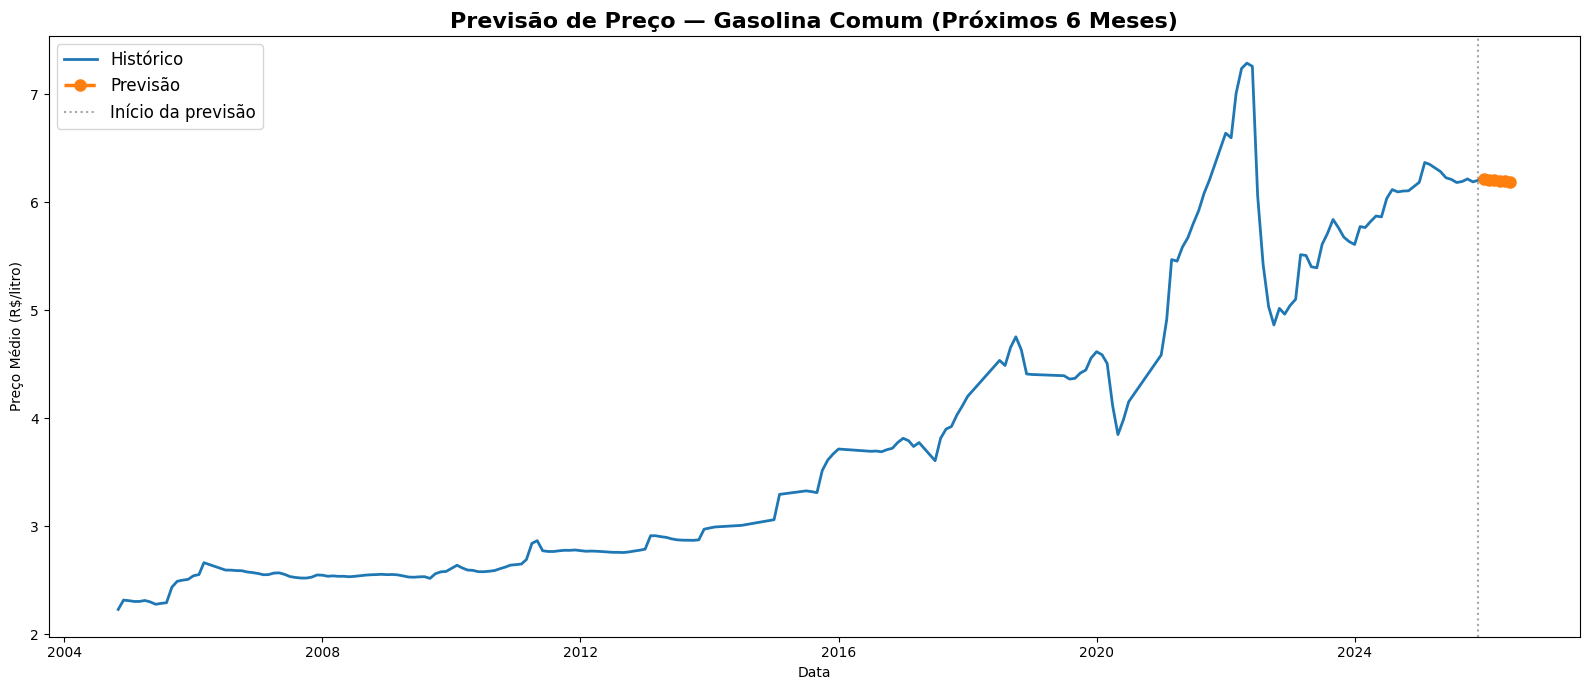

In [8]:
fig, ax = plt.subplots(figsize=(16, 7))

historico = df_features.copy()
historico['data'] = construir_coluna_data(historico)

ax.plot(historico['data'], historico['preco_medio'], label='Histórico', linewidth=2, color='#1f77b4')
ax.plot(previsoes['data'], previsoes['preco_medio'], label='Previsão', linewidth=2.5,
        color='#ff7f0e', marker='o', markersize=8, linestyle='--')
ax.axvline(historico['data'].max(), color='gray', linestyle=':', alpha=0.7, label='Início da previsão')

ax.set_title('Previsão de Preço — Gasolina Comum (Próximos 6 Meses)', fontsize=16, fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Preço Médio (R$/litro)')
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('../data/processed/fig_previsao.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.5 — Clustering de Municípios por Perfil de Preço

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

with duckdb.connect() as con:
    df_mun = con.execute(f"""
        SELECT estado_sigla, municipio,
               AVG(valor_venda)     AS preco_medio,
               STDDEV(valor_venda)  AS preco_std,
               MIN(valor_venda)     AS preco_min,
               MAX(valor_venda)     AS preco_max,
               COUNT(*)             AS n_registros
        FROM read_parquet('{PARQUET}')
        WHERE produto_padronizado = 'Gasolina Comum'
        GROUP BY estado_sigla, municipio
        HAVING COUNT(*) >= 50
    """).fetchdf()

df_mun['amplitude']     = df_mun['preco_max'] - df_mun['preco_min']
df_mun['coef_variacao'] = df_mun['preco_std'] / df_mun['preco_medio']
df_mun = df_mun.dropna()

print(f"Municípios para clustering: {len(df_mun):,}")

feature_cols = ['preco_medio', 'preco_std', 'amplitude', 'coef_variacao']
X_scaled = StandardScaler().fit_transform(df_mun[feature_cols])
df_mun['cluster'] = KMeans(n_clusters=5, random_state=42, n_init=10).fit_predict(X_scaled)

perfil = df_mun.groupby('cluster')[feature_cols].mean().round(4)
perfil['n_municipios'] = df_mun.groupby('cluster').size()

inercias = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inercias.append({'k': k, 'inercia': km.inertia_})

resultado_cluster = {
    'dados_clusterizados': df_mun,
    'perfil_clusters':     perfil,
    'inercias':            pd.DataFrame(inercias),
}

print("\n=== Perfil dos Clusters ===")
display(resultado_cluster['perfil_clusters'])

Municípios para clustering: 646

=== Perfil dos Clusters ===


,preco_medio,preco_std,amplitude,coef_variacao,n_municipios
cluster,,,,,
0,2.5352,0.1837,0.9268,0.0726,85
1,3.4578,1.3549,5.8414,0.3920,226
2,3.8310,1.4856,5.9608,0.3878,74
3,3.1826,1.2049,5.8104,0.3786,161
4,2.8653,0.3118,1.7679,0.1092,100


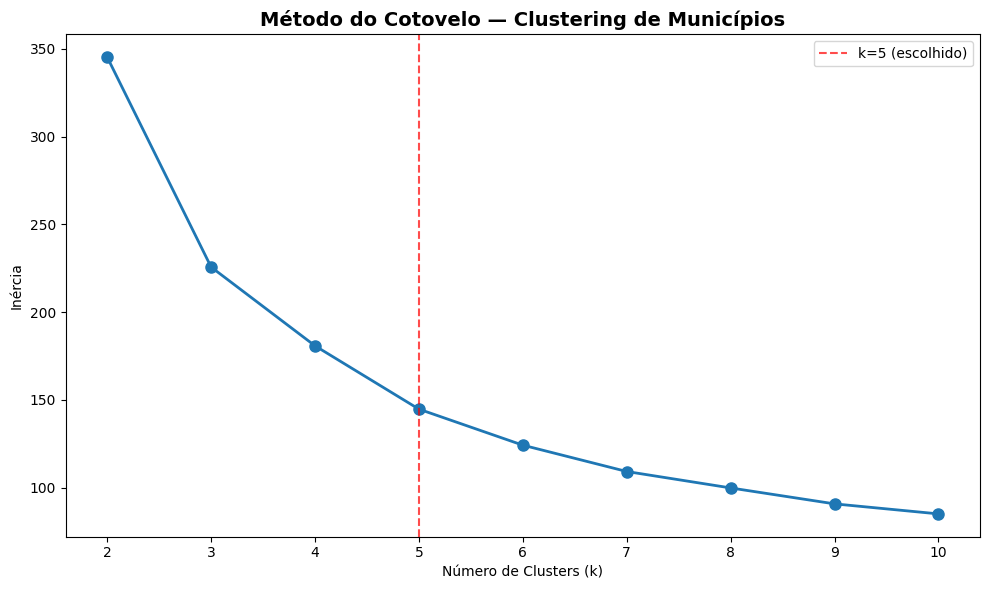

In [10]:
inercias = resultado_cluster['inercias']

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(inercias['k'], inercias['inercia'], marker='o', linewidth=2, markersize=8)
ax.set_title('Método do Cotovelo — Clustering de Municípios', fontsize=14, fontweight='bold')
ax.set_xlabel('Número de Clusters (k)')
ax.set_ylabel('Inércia')
ax.axvline(5, color='red', linestyle='--', alpha=0.7, label='k=5 (escolhido)')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/fig_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

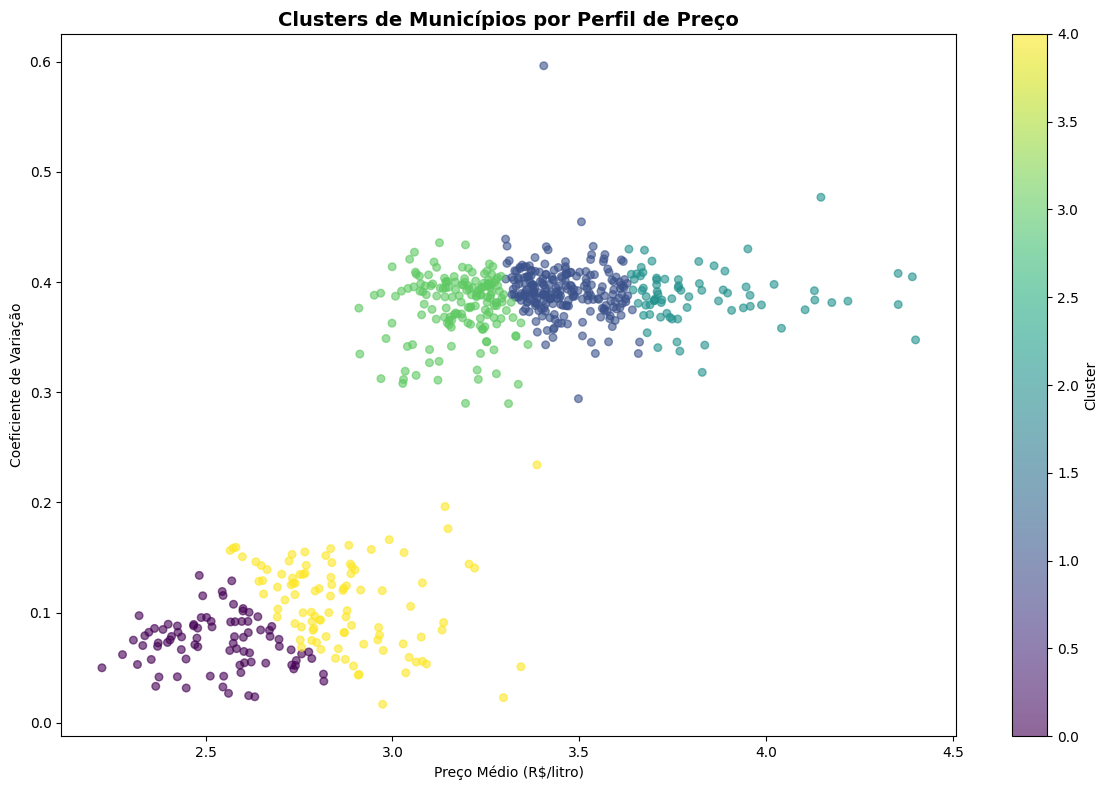

In [11]:
dados_cluster = resultado_cluster['dados_clusterizados']

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(
    dados_cluster['preco_medio'], dados_cluster['coef_variacao'],
    c=dados_cluster['cluster'], cmap='viridis', alpha=0.6, s=30
)
ax.set_title('Clusters de Municípios por Perfil de Preço', fontsize=14, fontweight='bold')
ax.set_xlabel('Preço Médio (R$/litro)')
ax.set_ylabel('Coeficiente de Variação')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.savefig('../data/processed/fig_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

---
**Próximo passo:** [05_correlacao.ipynb](05_correlacao.ipynb) — Correlação entre combustível, dólar e Brent
